## Visualizaciones TFG RITMO

1. Tablas LaTeX de resultados finales
2. Bar charts MSE por técnica x horizonte
3. Interpretabilidad HMM: regímenes, transiciones, embeddings

In [1]:
import os, sys, re
import numpy as np
import matplotlib.pyplot as plt
import torch

while not os.path.exists("run.py"):
    os.chdir("..")
sys.path.insert(0, ".")

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS_OI = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']

PRED_LENS = [96, 192, 336, 720]
DS_ORDER = ['ETTh1', 'ETTh2', 'Weather', 'custom']
DS_LABELS = {'ETTh1': 'ETTh1', 'ETTh2': 'ETTh2', 'Weather': 'Weather', 'custom': 'Electricity'}

# Best RITMO config per dataset (from K sweep)
RITMO_BEST = {
    'ETTh1': 'hmm_soft_residual_K4',
    'ETTh2': 'hmm_soft_K8',
    'Weather': 'hmm_soft_K8',
    'custom': 'hmm_soft_residual_K3',
}
BASELINES = ['patching', 'decomposition', 'foundation', 'text_based', 'discretization']

# Column order: RITMO first, then baselines
COL_ORDER = ['RITMO'] + BASELINES

# Names = technique category, NOT the example method
COL_NAMES = {
    'RITMO': 'RITMO (Ours)',
    'patching': 'Patching',
    'decomposition': 'Decomposition',
    'foundation': 'Foundation',
    'text_based': 'Text-based',
    'discretization': 'Discretization',
}
COL_COLORS = {
    'RITMO': COLORS_OI[5],
    'patching': COLORS_OI[1],
    'decomposition': COLORS_OI[2],
    'foundation': COLORS_OI[4],
    'text_based': COLORS_OI[6],
    'discretization': COLORS_OI[7],
}

# Load all final results
# IMPORTANT: metrics.npy order is [mae, mse, rmse, mape, mspe]
from collections import defaultdict
rows = []
results_dir = "./results"
for d in os.listdir(results_dir):
    m = re.search(r"_final_([\w]+?)(?:_K(\d+))?_0$", d)
    ds_m = re.match(r"plan_a_(\w+?)_96_(\d+)_", d)
    if not m or not ds_m:
        continue
    mpath = os.path.join(results_dir, d, "metrics.npy")
    if not os.path.exists(mpath):
        continue
    k_part = f"_K{m.group(2)}" if m.group(2) else ""
    technique = m.group(1) + k_part
    dataset = ds_m.group(1)
    pred_len = int(ds_m.group(2))
    metrics = np.load(mpath)
    mae, mse = float(metrics[0]), float(metrics[1])
    rows.append((dataset, technique, pred_len, mse, mae))

# Aggregate
data_raw = defaultdict(lambda: defaultdict(dict))
for dataset, technique, pred_len, mse, mae in rows:
    data_raw[dataset][technique][pred_len] = (mse, mae)

# Unified data: merge RITMO variants into single "RITMO" column
data = defaultdict(lambda: defaultdict(dict))
for ds in DS_ORDER:
    ritmo_key = RITMO_BEST[ds]
    if ritmo_key in data_raw[ds]:
        data[ds]['RITMO'] = data_raw[ds][ritmo_key]
    for b in BASELINES:
        if b in data_raw[ds]:
            data[ds][b] = data_raw[ds][b]

print(f"Loaded {len(rows)} results across {len(data)} datasets")
for ds in DS_ORDER:
    ritmo_key = RITMO_BEST[ds]
    avg = np.mean([data[ds]['RITMO'].get(pl, (999,))[0] for pl in PRED_LENS])
    print(f"  {DS_LABELS[ds]}: RITMO={ritmo_key}, avg MSE={avg:.6f}")
os.makedirs('notebooks/figures', exist_ok=True)

Loaded 100 results across 4 datasets
  ETTh1: RITMO=hmm_soft_residual_K4, avg MSE=0.076627
  ETTh2: RITMO=hmm_soft_K8, avg MSE=0.198352
  Weather: RITMO=hmm_soft_K8, avg MSE=0.001653
  Electricity: RITMO=hmm_soft_residual_K3, avg MSE=0.351567


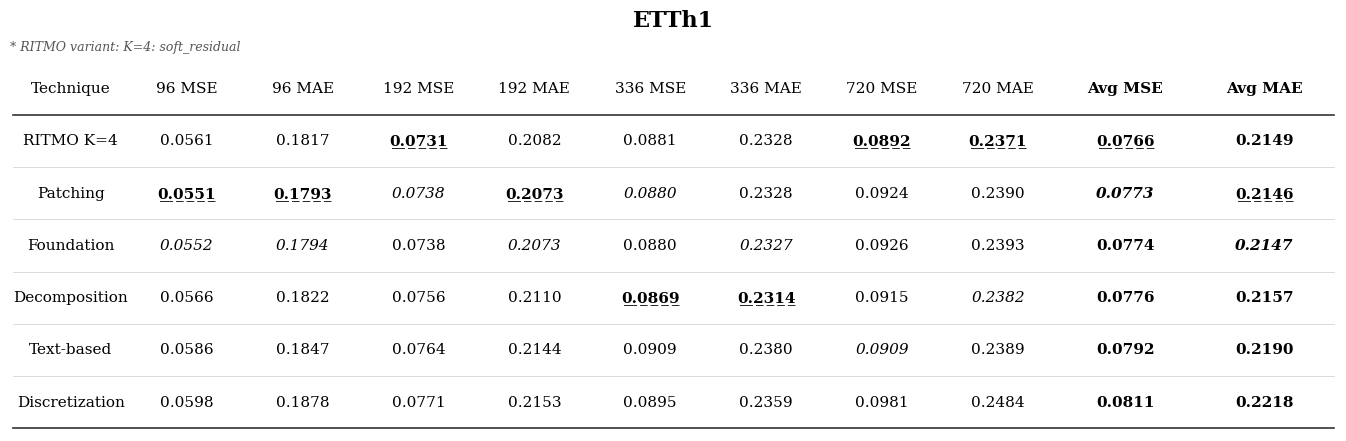

Saved: notebooks/figures/table_etth1.png


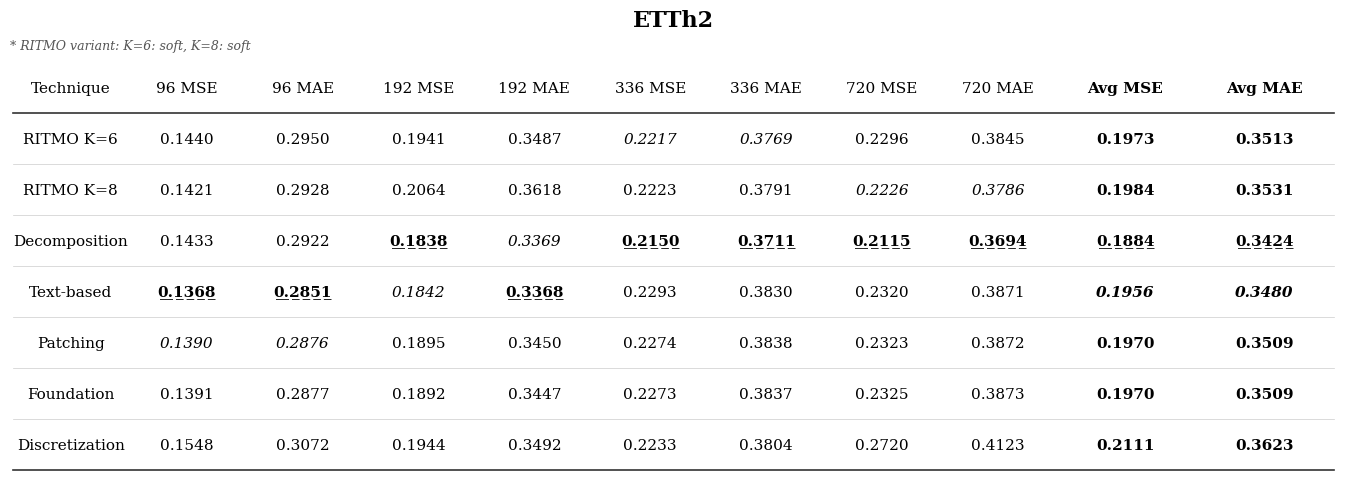

Saved: notebooks/figures/table_etth2.png


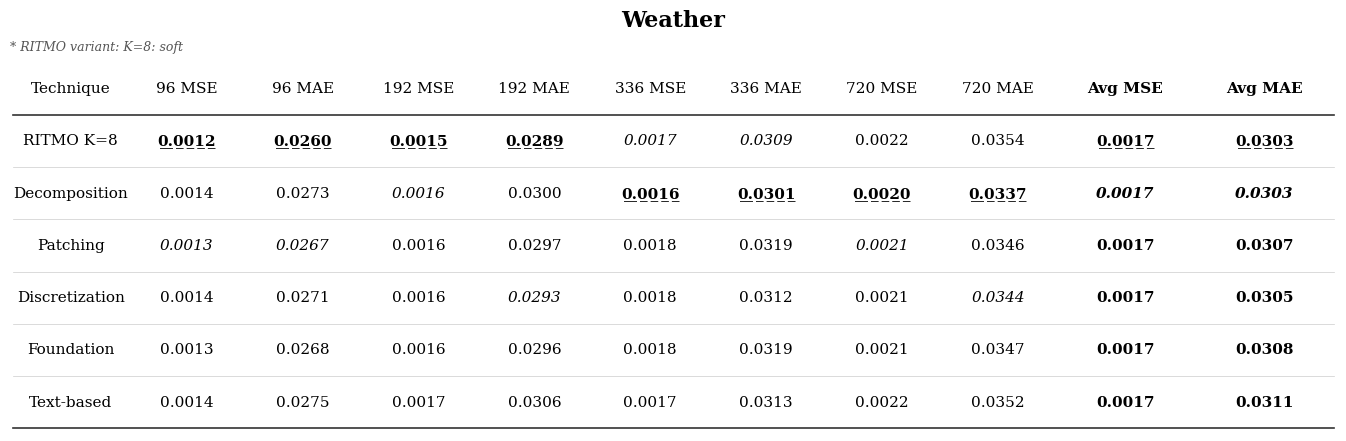

Saved: notebooks/figures/table_weather.png


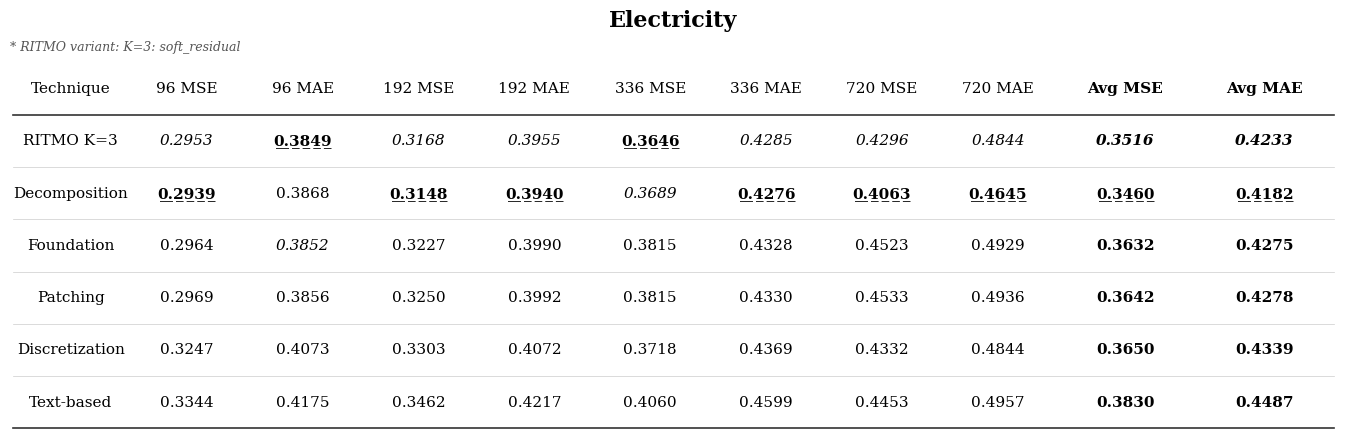

Saved: notebooks/figures/table_electricity.png


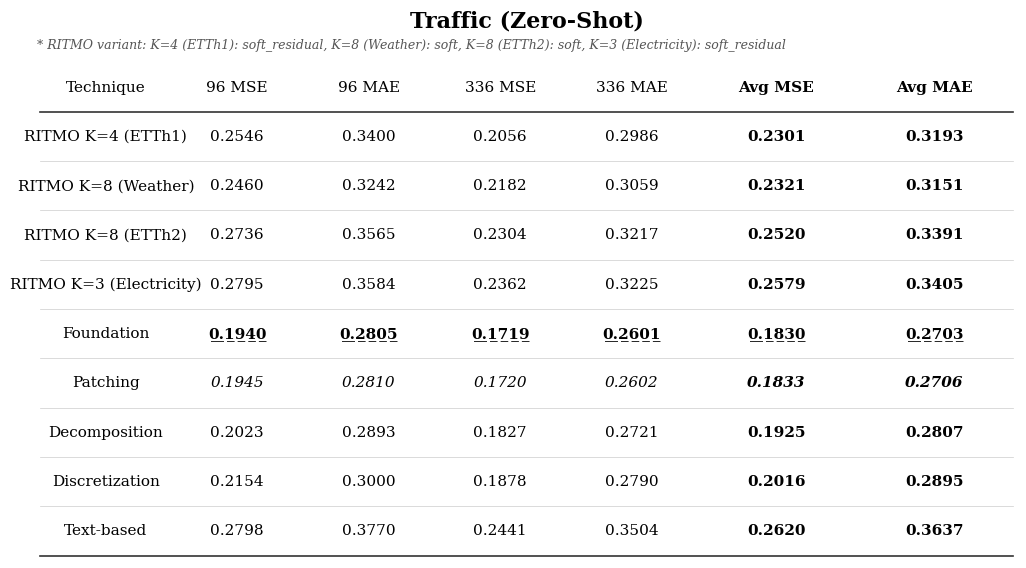

Saved: notebooks/figures/table_traffic_zeroshot.png


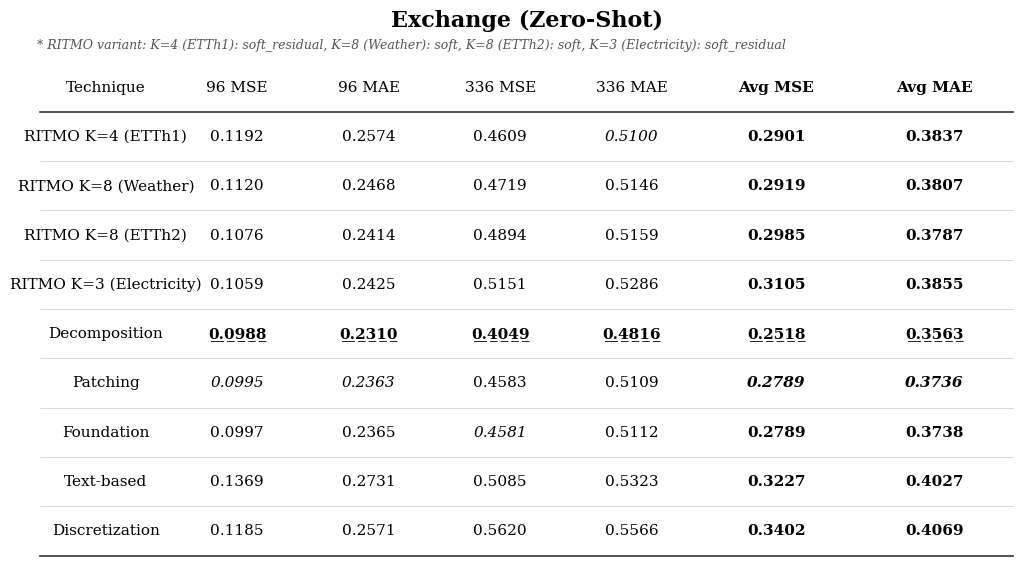

Saved: notebooks/figures/table_exchange_zeroshot.png


In [2]:
# === TABLAS PAPER-STYLE con plottable ===

import os, re, numpy as np, matplotlib.pyplot as plt
import pandas as pd
from plottable import Table, ColumnDefinition
from collections import defaultdict

# --- Load ALL results ---
all_rows = []
for d in os.listdir('./results'):
    m = re.search(r'_final_([\w]+?)(?:_K(\d+))?_0$', d)
    ds_m = re.match(r'plan_a_(\w+?)_96_(\d+)_', d)
    if not m or not ds_m:
        continue
    mpath = os.path.join('./results', d, 'metrics.npy')
    if not os.path.exists(mpath):
        continue
    k_part = f'_K{m.group(2)}' if m.group(2) else ''
    technique = m.group(1) + k_part
    dataset = ds_m.group(1)
    pred_len = int(ds_m.group(2))
    metrics = np.load(mpath)
    mae, mse = float(metrics[0]), float(metrics[1])
    all_rows.append((dataset, technique, pred_len, mse, mae))

zs_rows = []
for d in os.listdir('./results'):
    m = re.search(r'_zeroshot_(Traffic|Exchange)_([\w]+?)_0$', d)
    ds_m = re.match(r'plan_a_(\w+?)_96_(\d+)_', d)
    if not m or not ds_m:
        continue
    mpath = os.path.join('./results', d, 'metrics.npy')
    if not os.path.exists(mpath):
        continue
    target = m.group(1)
    technique = m.group(2)
    pred_len = int(ds_m.group(2))
    metrics = np.load(mpath)
    mae, mse = float(metrics[0]), float(metrics[1])
    zs_rows.append((target, technique, pred_len, mse, mae))

data_all = defaultdict(lambda: defaultdict(dict))
for ds, tech, pl, mse, mae in all_rows:
    data_all[ds][tech][pl] = (mse, mae)
for tgt, tech, pl, mse, mae in zs_rows:
    data_all[tgt][tech][pl] = (mse, mae)

# --- Naming ---
TECH_NAMES = {
    'patching': 'Patching', 'decomposition': 'Decomposition',
    'foundation': 'Foundation', 'text_based': 'Text-based',
    'discretization': 'Discretization',
}

def tech_display(t):
    if t in TECH_NAMES:
        return TECH_NAMES[t]
    if t.startswith('hmm_'):
        k = t.split('_K')[1] if '_K' in t else '?'
        return f'RITMO K={k}'
    for s in ['ETTh1', 'ETTh2', 'Weather', 'Electricity']:
        if t.startswith(s + '_hmm_'):
            k = t.split('_K')[1] if '_K' in t else '?'
            return f'RITMO K={k} ({s})'
    return t

def render_table(ds_key, ds_label, pred_lens, save_path):
    techs_dict = data_all[ds_key]
    if not techs_dict:
        print(f"No data for {ds_label}")
        return

    # Sort: RITMO first, then baselines
    ritmo_techs, baseline_techs = [], []
    for t in techs_dict:
        avg = np.nanmean([techs_dict[t].get(pl, (np.nan,))[0] for pl in pred_lens])
        (ritmo_techs if 'hmm' in t else baseline_techs).append((t, avg))
    ritmo_techs.sort(key=lambda x: x[1])
    baseline_techs.sort(key=lambda x: x[1])
    tech_order = [t for t, _ in ritmo_techs] + [t for t, _ in baseline_techs]

    # Build DataFrame: rows=techniques, cols=horizons (MSE + MAE interleaved)
    records = []
    for t in tech_order:
        row = {'Technique': tech_display(t)}
        for pl in pred_lens:
            mse, mae = techs_dict[t].get(pl, (np.nan, np.nan))
            row[f'{pl} MSE'] = mse
            row[f'{pl} MAE'] = mae
        mse_vals = [techs_dict[t].get(pl, (np.nan,))[0] for pl in pred_lens]
        mae_vals = [techs_dict[t].get(pl, (np.nan, np.nan))[1] for pl in pred_lens]
        row['Avg MSE'] = np.nanmean(mse_vals)
        row['Avg MAE'] = np.nanmean(mae_vals)
        records.append(row)

    df = pd.DataFrame(records).set_index('Technique')
    for col in df.columns:
        df[col] = df[col].round(4)

    # Column definitions (no heatmap, bold best per column)
    col_defs = []
    for col in df.columns:
        is_avg = col.startswith('Avg')
        col_defs.append(ColumnDefinition(
            name=col, width=1.2 if is_avg else 1.0,
            textprops={'fontsize': 11, 'fontweight': 'bold' if is_avg else 'normal',
                       'ha': 'center'},
            formatter='{:.4f}',
        ))

    # Bold + underline best value per column
    best_per_col = {}
    second_per_col = {}
    for col in df.columns:
        vals = df[col].dropna().sort_values()
        if len(vals) >= 1:
            best_per_col[col] = vals.index[0]
        if len(vals) >= 2:
            second_per_col[col] = vals.index[1]

    # Figure
    n_cols = len(df.columns)
    max_name = max(len(t) for t in df.index)
    fig_w = max(12, 1.3 * n_cols + max_name * 0.08 + 3)
    fig_h = max(2.5, 0.55 * len(df) + 1.5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # Index column wider for long names
    idx_width = 2.2 if max_name > 15 else 1.5
    col_defs.insert(0, ColumnDefinition(name='index', width=idx_width,
        textprops={'fontsize': 11, 'ha': 'left'}))

    tab = Table(
        df, column_definitions=col_defs,
        textprops={'fontsize': 11, 'ha': 'center'},
        row_dividers=True,
        row_divider_kw={'linewidth': 0.5, 'linestyle': '-', 'color': '#CCCCCC'},
        col_label_divider=True,
        col_label_divider_kw={'linewidth': 1.2, 'linestyle': '-', 'color': '#333333'},
        footer_divider=True,
        footer_divider_kw={'linewidth': 1.2, 'linestyle': '-', 'color': '#333333'},
        ax=ax,
    )

    # Underline best, bold 2nd per column
    for col_idx, col in enumerate(df.columns):
        for row_idx, tech in enumerate(df.index):
            cell = tab.cells[row_idx, col_idx + 1]  # +1 for index col
            if col in best_per_col and tech == best_per_col[col]:
                cell.text.set_fontweight('bold')
                cell.text.set_text('\u0332'.join(cell.text.get_text()) + '\u0332')
            elif col in second_per_col and tech == second_per_col[col]:
                cell.text.set_fontstyle('italic')

    # Subtitle with RITMO variant details
    ritmo_rows = [t for t in df.index if 'RITMO' in t]
    if ritmo_rows:
        techs_in_ds = data_all[ds_key]
        details = []
        for t_raw in tech_order:
            if 'hmm' not in t_raw:
                continue
            if t_raw.startswith('hmm_'):
                variant = t_raw.replace('hmm_', '').rsplit('_K', 1)[0]
                k_val = t_raw.rsplit('_K', 1)[1]
                details.append(f'K={k_val}: {variant}')
            else:
                for s in ['ETTh1', 'ETTh2', 'Weather', 'Electricity']:
                    if t_raw.startswith(s + '_hmm_'):
                        variant = t_raw[len(s)+1:].replace('hmm_', '').rsplit('_K', 1)[0]
                        k_val = t_raw.rsplit('_K', 1)[1]
                        details.append(f'K={k_val} ({s}): {variant}')
        if details:
            subtitle = '* RITMO variant: ' + ', '.join(details)
            ax.text(0.0, 1.02, subtitle, transform=ax.transAxes,
                    fontsize=9, fontstyle='italic', color='#555555', va='bottom')

    ax.set_title(ds_label, fontsize=16, fontweight='bold', pad=25)
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_path}")


os.makedirs('notebooks/figures', exist_ok=True)

# In-domain (4 horizontes)
for ds_key, ds_label in [('ETTh1', 'ETTh1'), ('ETTh2', 'ETTh2'),
                           ('Weather', 'Weather'), ('custom', 'Electricity')]:
    render_table(ds_key, ds_label, [96, 192, 336, 720],
                 f'notebooks/figures/table_{ds_label.lower()}.png')

# Zero-shot (2 horizontes)
for tgt in ['Traffic', 'Exchange']:
    render_table(tgt, f'{tgt} (Zero-Shot)', [96, 336],
                 f'notebooks/figures/table_{tgt.lower()}_zeroshot.png')


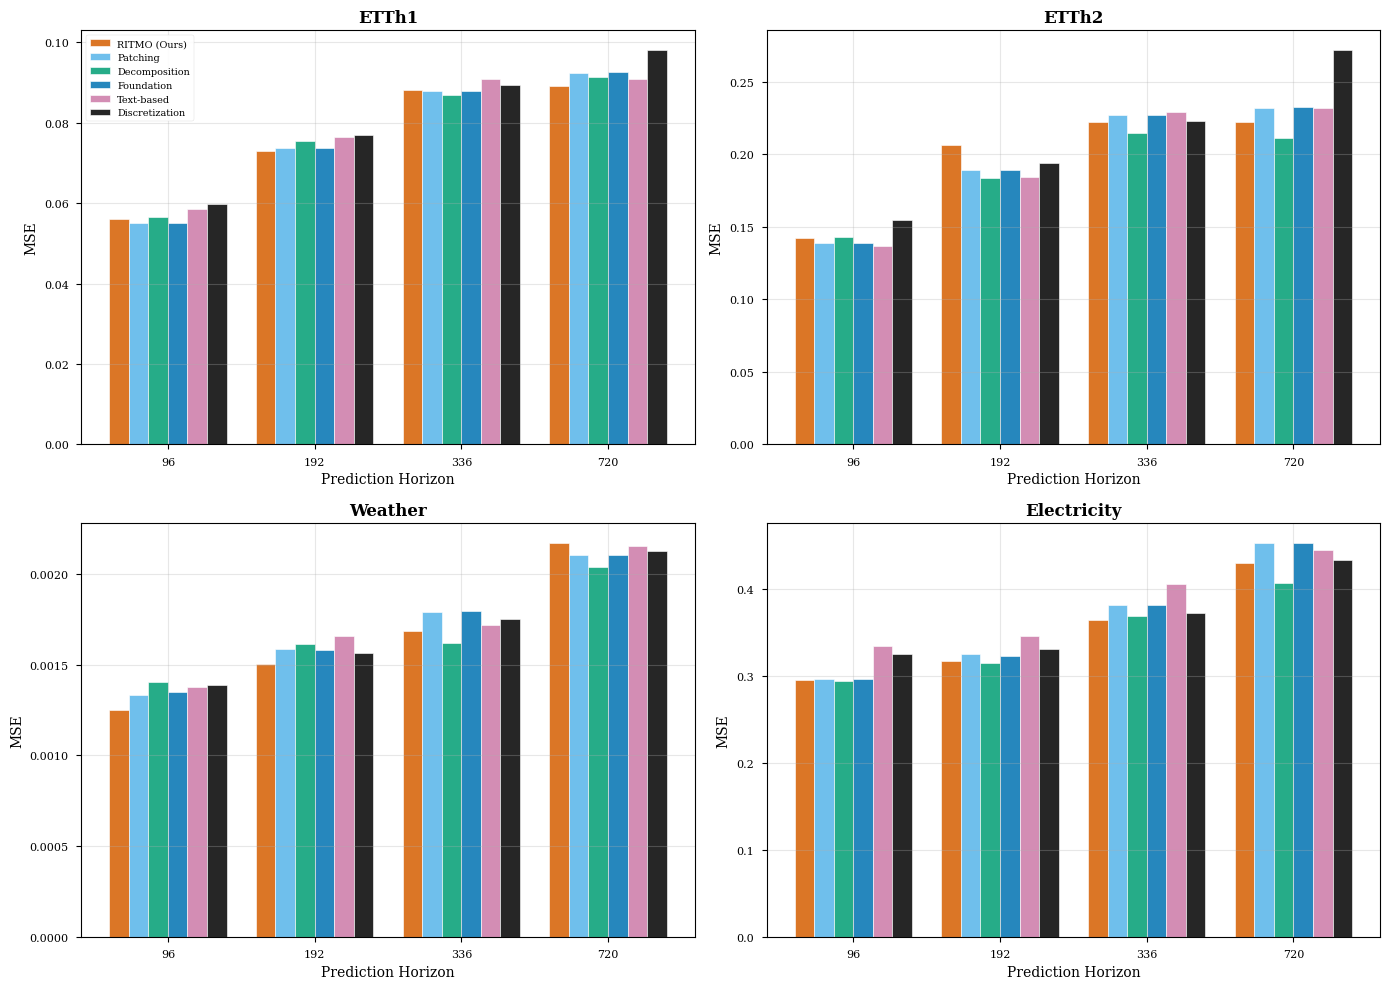

Saved: notebooks/figures/mse_comparison_all.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, ds in enumerate(DS_ORDER):
    ax = axes[idx]
    ds_label = DS_LABELS[ds]
    n_techs = len(COL_ORDER)
    x = np.arange(len(PRED_LENS))
    width = 0.8 / n_techs

    for i, t in enumerate(COL_ORDER):
        vals = [data[ds][t].get(pl, (float('nan'),))[0] for pl in PRED_LENS]
        ax.bar(x + i * width - 0.4 + width/2, vals, width,
               label=COL_NAMES[t], color=COL_COLORS[t], alpha=0.85,
               edgecolor='white', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([str(pl) for pl in PRED_LENS])
    ax.set_xlabel('Prediction Horizon', fontsize=10)
    ax.set_ylabel('MSE', fontsize=10)
    ax.set_title(ds_label, fontweight='bold', fontsize=12)

axes[0].legend(fontsize=7, loc='upper left', framealpha=0.9)
plt.tight_layout()
fig.savefig('notebooks/figures/mse_comparison_all.png', dpi=300, bbox_inches='tight')
fig.savefig('notebooks/figures/mse_comparison_all.pdf', dpi=300, bbox_inches='tight')  # auto-vectorial
fig.savefig('notebooks/figures/mse_comparison_all.svg', dpi=300, bbox_inches='tight')  # auto-vectorial
plt.show()
print("Saved: notebooks/figures/mse_comparison_all.png")

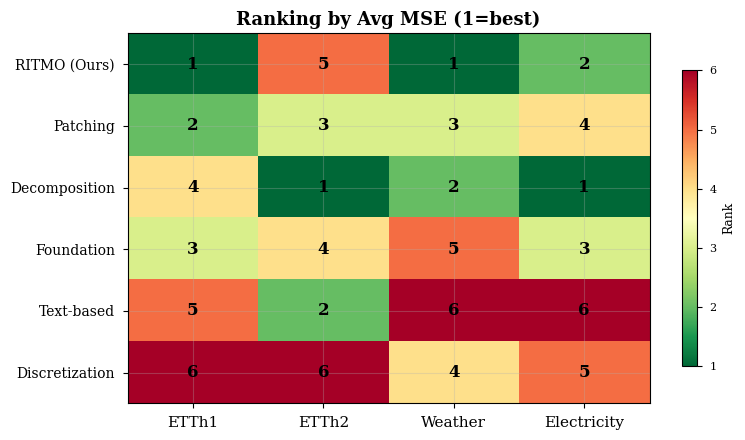

Saved: notebooks/figures/ranking_heatmap.png


In [4]:
# Ranking heatmap: all 6 methods including RITMO
rank_matrix = np.zeros((len(COL_ORDER), len(DS_ORDER)))
for j, ds in enumerate(DS_ORDER):
    avgs = [(t, np.mean([data[ds][t].get(pl, (999,))[0] for pl in PRED_LENS]))
            for t in COL_ORDER]
    avgs_sorted = sorted(avgs, key=lambda x: x[1])
    for rank, (t, _) in enumerate(avgs_sorted, 1):
        i = COL_ORDER.index(t)
        rank_matrix[i, j] = rank

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(rank_matrix, cmap='RdYlGn_r', aspect='auto',
               vmin=1, vmax=len(COL_ORDER))
ax.set_xticks(range(len(DS_ORDER)))
ax.set_xticklabels([DS_LABELS[ds] for ds in DS_ORDER], fontsize=11)
ax.set_yticks(range(len(COL_ORDER)))
ax.set_yticklabels([COL_NAMES[t] for t in COL_ORDER], fontsize=10)

for i in range(len(COL_ORDER)):
    for j in range(len(DS_ORDER)):
        ax.text(j, i, f"{int(rank_matrix[i,j])}", ha='center', va='center',
                fontsize=12, fontweight='bold')

ax.set_title('Ranking by Avg MSE (1=best)', fontweight='bold', fontsize=13)
plt.colorbar(im, ax=ax, label='Rank', shrink=0.8)
plt.tight_layout()
fig.savefig('notebooks/figures/ranking_heatmap.png', dpi=300, bbox_inches='tight')
fig.savefig('notebooks/figures/ranking_heatmap.pdf', dpi=300, bbox_inches='tight')  # auto-vectorial
fig.savefig('notebooks/figures/ranking_heatmap.svg', dpi=300, bbox_inches='tight')  # auto-vectorial
plt.show()
print("Saved: notebooks/figures/ranking_heatmap.png")

## Interpretabilidad HMM

Visualización de los regímenes aprendidos por el HMM en Weather (donde RITMO gana).

In [5]:
from data_provider.data_factory import data_provider
from hmm import forward_backward_batch
import argparse

# Load Weather HMM cache (K=8, best)
cache = torch.load('./cache/hmm_weather_K8.pth', weights_only=False)
A = cache['A'].numpy() if isinstance(cache['A'], torch.Tensor) else cache['A']
pi = cache['pi'].numpy() if isinstance(cache['pi'], torch.Tensor) else cache['pi']
mu = cache['mu'].numpy() if isinstance(cache['mu'], torch.Tensor) else cache['mu']
sigma = cache['sigma'].numpy() if isinstance(cache['sigma'], torch.Tensor) else cache['sigma']
K = len(mu)
print(f"K={K} states loaded")
print(f"  mu: {np.round(mu, 4)}")
print(f"  sigma: {np.round(sigma, 4)}")

K=8 states loaded
  mu: [-0.6806  0.6263 -0.3576 -1.3552  1.9975 -0.9478  1.2003  0.0849]
  sigma: [0.09   0.1924 0.1291 0.253  0.5159 0.0953 0.221  0.1657]


Segment: 1920 timesteps, range [-2.74, 3.44]
HMM mu range: [-1.36, 2.00]


  S0 (mu=-1.36): 14.4%
  S1 (mu=-0.95): 10.5%
  S2 (mu=-0.68): 10.5%
  S3 (mu=-0.36): 13.5%
  S4 (mu=0.08): 14.3%
  S5 (mu=0.63): 15.2%
  S6 (mu=1.20): 14.6%
  S7 (mu=2.00): 7.0%


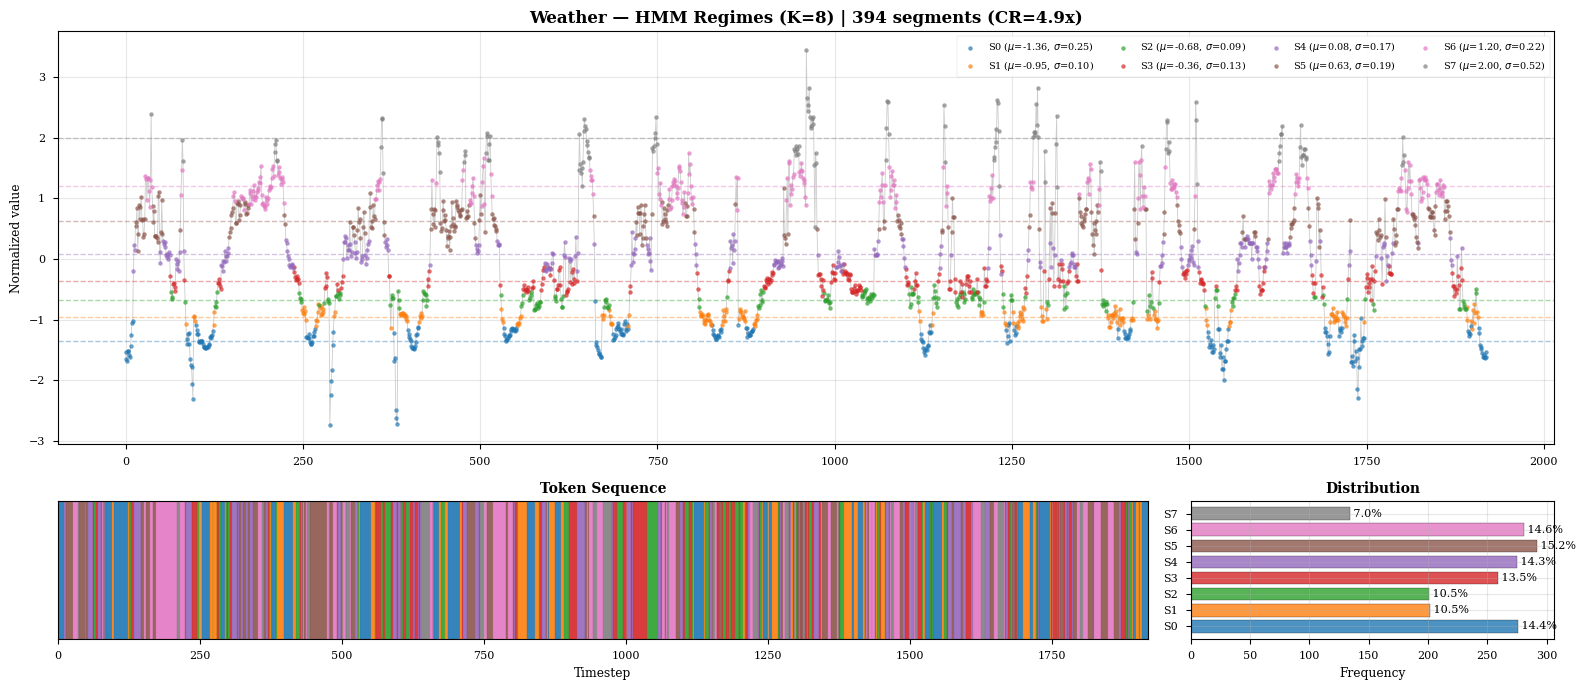

Saved: notebooks/figures/weather_regimes.png


In [6]:
# Load Weather test data with RevIN per-window normalization (same as pipeline)
import pandas as pd

df = pd.read_csv('./dataset/weather/weather.csv')
values = df['OT'].values.astype(float)

# RevIN per-window normalization (identical to pipeline/exp_plan_a)
seq_len = 96
n_train = int(len(values) * 0.7)
train_raw = values[:n_train]
windows = []
for start in range(0, len(train_raw) - seq_len + 1, seq_len):
    w = train_raw[start:start + seq_len]
    w_mean, w_std = w.mean(), max(w.std(), 1e-5)
    windows.append((w - w_mean) / w_std)
train_norm = np.concatenate(windows)

# Take test segment and normalize per-window too
test_start = int(len(values) * 0.8)
test_raw = values[test_start:]
test_windows = []
for start in range(0, len(test_raw) - seq_len + 1, seq_len):
    w = test_raw[start:start + seq_len]
    w_mean, w_std = w.mean(), max(w.std(), 1e-5)
    test_windows.append((w - w_mean) / w_std)
segment = np.concatenate(test_windows[:20])  # 20 windows = 1920 timesteps

print(f"Segment: {len(segment)} timesteps, range [{segment.min():.2f}, {segment.max():.2f}]")
print(f"HMM mu range: [{mu.min():.2f}, {mu.max():.2f}]")

# Run forward-backward
gamma, _, _ = forward_backward_batch(
    segment.reshape(1, -1), A, pi, mu, sigma, need_xi=False
)
gamma = gamma[0]  # [T, K]
states = np.argmax(gamma, axis=1)

# Sort states by mu
state_order = np.argsort(mu)
state_map = {old: new for new, old in enumerate(state_order)}
states_mapped = np.array([state_map[s] for s in states])
mu_sorted = mu[state_order]
sigma_sorted = sigma[state_order]

# Colors
colors_tokens = [plt.cm.tab10(i) for i in range(K)]
state_colors = colors_tokens

# Check state distribution
for k in range(K):
    pct = 100 * np.sum(states_mapped == k) / len(states_mapped)
    print(f"  S{k} (mu={mu_sorted[k]:.2f}): {pct:.1f}%")

# --- Figure: serie coloreada + barra tokens + distribucion ---
t_viz = len(segment)
fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], width_ratios=[3, 1])
ax_series = fig.add_subplot(gs[0, :])
ax_bar = fig.add_subplot(gs[1, 0])
ax_stats = fig.add_subplot(gs[1, 1])

# Series: gray line + colored scatter per state
ax_series.plot(segment[:t_viz], color='gray', linewidth=0.6, alpha=0.4, zorder=1)
for k in range(K):
    mask = states_mapped[:t_viz] == k
    if np.any(mask):
        ax_series.scatter(
            np.where(mask)[0], segment[:t_viz][mask],
            color=colors_tokens[k], s=8, alpha=0.7, zorder=2,
            label=f'S{k} ($\\mu$={mu_sorted[k]:.2f}, $\\sigma$={sigma_sorted[k]:.2f})'
        )
        ax_series.axhline(mu_sorted[k], color=colors_tokens[k], linestyle='--', linewidth=1, alpha=0.4)

ax_series.set_ylabel('Normalized value')
state_changes = np.sum(states_mapped[1:] != states_mapped[:-1])
cr = len(segment) / (state_changes + 1)
ax_series.set_title(f'Weather — HMM Regimes (K={K}) | {state_changes+1} segments (CR={cr:.1f}x)',
                     fontweight='bold', fontsize=12)
ax_series.legend(loc='upper right', fontsize=7, ncol=4, framealpha=0.9)
ax_series.grid(alpha=0.3)

# Token bar
prev = states_mapped[0]
start = 0
for t in range(1, min(t_viz, len(states_mapped))):
    if states_mapped[t] != prev or t == min(t_viz, len(states_mapped)) - 1:
        ax_bar.axvspan(start, t, color=colors_tokens[prev], alpha=0.9)
        start = t
        prev = states_mapped[t]
ax_bar.set_xlim(0, t_viz)
ax_bar.set_yticks([])
ax_bar.set_xlabel('Timestep')
ax_bar.set_title('Token Sequence', fontweight='bold', fontsize=10)

# Distribution
token_counts = [np.sum(states_mapped == k) for k in range(K)]
ax_stats.barh(range(K), token_counts, color=colors_tokens, alpha=0.8, edgecolor='black')
ax_stats.set_yticks(range(K))
ax_stats.set_yticklabels([f'S{k}' for k in range(K)])
ax_stats.set_xlabel('Frequency')
ax_stats.set_title('Distribution', fontweight='bold', fontsize=10)
ax_stats.grid(alpha=0.3, axis='x')
for k in range(K):
    pct = 100 * token_counts[k] / len(states_mapped)
    ax_stats.text(token_counts[k], k, f' {pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
fig.savefig('notebooks/figures/weather_regimes.png', dpi=300, bbox_inches='tight')
fig.savefig('notebooks/figures/weather_regimes.pdf', dpi=300, bbox_inches='tight')  # auto-vectorial
fig.savefig('notebooks/figures/weather_regimes.svg', dpi=300, bbox_inches='tight')  # auto-vectorial
plt.show()
print("Saved: notebooks/figures/weather_regimes.png")

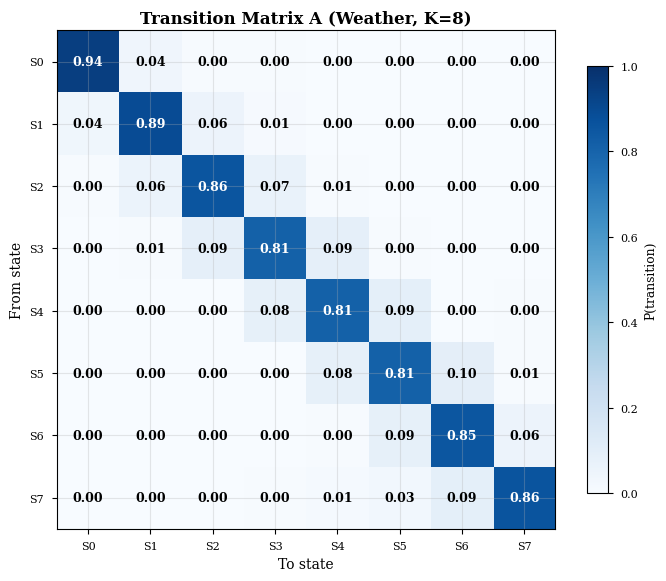

Saved: notebooks/figures/weather_transitions.png


In [7]:
# --- Figure 2: Transition matrix ---
fig, ax = plt.subplots(figsize=(7, 6))
A_sorted = A[state_order][:, state_order]
im = ax.imshow(A_sorted, cmap='Blues', vmin=0, vmax=1)
for i in range(K):
    for j in range(K):
        val = A_sorted[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(range(K))
ax.set_yticks(range(K))
ax.set_xticklabels([f'S{i}' for i in range(K)])
ax.set_yticklabels([f'S{i}' for i in range(K)])
ax.set_xlabel('To state', fontsize=10)
ax.set_ylabel('From state', fontsize=10)
ax.set_title('Transition Matrix A (Weather, K=8)', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='P(transition)', shrink=0.8)
plt.tight_layout()
fig.savefig('notebooks/figures/weather_transitions.png', dpi=300, bbox_inches='tight')
fig.savefig('notebooks/figures/weather_transitions.pdf', dpi=300, bbox_inches='tight')  # auto-vectorial
fig.savefig('notebooks/figures/weather_transitions.svg', dpi=300, bbox_inches='tight')  # auto-vectorial
plt.show()
print("Saved: notebooks/figures/weather_transitions.png")

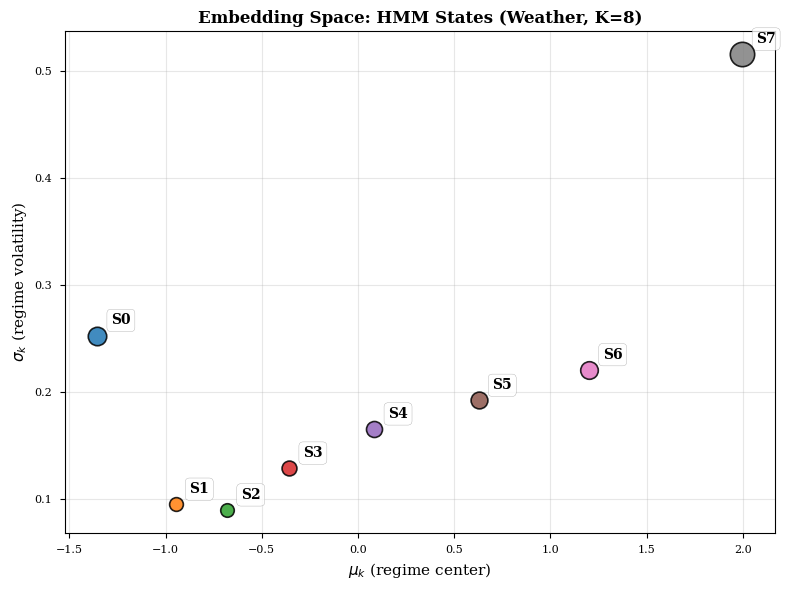

Saved: notebooks/figures/weather_embedding_space.png


In [8]:
# --- Figure 3: Embedding space scatter (mu vs sigma) ---
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(K):
    size = sigma_sorted[i] * 500 + 50
    ax.scatter(mu_sorted[i], sigma_sorted[i], s=size, c=[state_colors[i]],
               edgecolors='black', linewidth=1.2, zorder=5, alpha=0.85)
    ax.annotate(f'S{i}', (mu_sorted[i], sigma_sorted[i]),
                textcoords="offset points", xytext=(10, 8),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

ax.set_xlabel(r'$\mu_k$ (regime center)', fontsize=11)
ax.set_ylabel(r'$\sigma_k$ (regime volatility)', fontsize=11)
ax.set_title('Embedding Space: HMM States (Weather, K=8)', fontweight='bold', fontsize=12)
plt.tight_layout()
fig.savefig('notebooks/figures/weather_embedding_space.png', dpi=300, bbox_inches='tight')
fig.savefig('notebooks/figures/weather_embedding_space.pdf', dpi=300, bbox_inches='tight')  # auto-vectorial
fig.savefig('notebooks/figures/weather_embedding_space.svg', dpi=300, bbox_inches='tight')  # auto-vectorial
plt.show()
print("Saved: notebooks/figures/weather_embedding_space.png")